# Event reconstruction for mono analysis

Our aim is to find the Hillas paramters for a simple monoscopic analysis.
refer to https://ctapipe.readthedocs.io/en/stable/auto_examples/tutorials/ctapipe_overview.html

For the file "gamma-diffuse_with_images_00.dl2.h5" 

Lets start with a bunch of imports...

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from ctapipe.io import EventSource
from ctapipe.visualization import CameraDisplay, ArrayDisplay
from ctapipe.reco import HillasReconstructor
from ctapipe.image import hillas_parameters, tailcuts_clean, timing_parameters
from ctapipe.image import brightest_island, number_of_islands, largest_island
import math
import astropy.units as u
from astropy.coordinates import SkyCoord, AltAz
from ctapipe.coordinates import CameraFrame
from ctapipe.coordinates.utils import altaz_to_righthanded_cartesian


Read the file...

In [2]:
dl1_file = "gamma-diffuse_with_images_00.dl2.h5"

source = EventSource(
    input_url = dl1_file,
    max_events = None
)
subarray = source.subarray

Table /configuration/simulation/run is missing column None for field run_number of container <class 'ctapipe.containers.SimulationConfigContainer'>. It will be skipped.


Find all events on any one telescope (lets say TEL_ID = 10)

- How many events are there?

So we use this TEL_ID to select a telescope and then make a list of all the events that triggered this particular telescope.

In [3]:
#Selecting one particular telescope for analysis
tel_id = 10

#Defining a list for all its events
mono_events = []

#Iterating through all the events and selecting the ones where the telescope with tel_id has triggered
for event in source:
    if tel_id in event.trigger.tels_with_trigger:
        mono_events.append(event)

Table /dl1/event/telescope/trigger is missing column event_type for field event_type of container <class 'ctapipe.containers.TelescopeTriggerContainer'>. It will be skipped.
Table /simulation/event/subarray/shower is missing column true_starting_grammage for field starting_grammage of container <class 'ctapipe.containers.SimulatedShowerContainer'>. It will be skipped.
Table /dl2/event/subarray/geometry/HillasReconstructor is missing column HillasReconstructor_ang_distance_uncert for field ang_distance_uncert of container <class 'ctapipe.containers.ReconstructedGeometryContainer'>. It will be skipped.
Table /dl1/event/telescope/parameters/tel_035 is missing column hillas_psi_uncertainty for field psi_uncertainty of container <class 'ctapipe.containers.HillasParametersContainer'>. It will be skipped.
Table /dl1/event/telescope/parameters/tel_035 is missing column hillas_transverse_cog_uncertainty for field transverse_cog_uncertainty of container <class 'ctapipe.containers.HillasParameter

In [5]:
#Printing the number of events where the telescope with tel_id has triggered
print(f"Number of events where telescope {tel_id} has triggered: {len(mono_events)}\n")



#printing the attributes of the mono_events list
print(f"\n Attributes of mono_events list: {dir(mono_events)}")

Number of events where telescope 10 has triggered: 7570


 Attributes of mono_events list: ['__add__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__imul__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__rmul__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', 'append', 'clear', 'copy', 'count', 'extend', 'index', 'insert', 'pop', 'remove', 'reverse', 'sort']


- Plot the image for different event ids
- Clean the image using `tailcuts_clean` (use event id = 5) - How to decide thresholds?
- Find the number of islands
- get the brightest island
- compute the Hillas parameters
- overlay the Hillas parameters on the plot
- Plot the arrival time at each pixel
- compute the timing profile using `timing_parameters`
- Repeat for another few events to get a feel
- Now, repeat for all events (for performance issues, use ~1000 events)
- Find the simulated energy value for each event
- Plot the Hillas/timing parameters with energy - The n

#### Plotting the image for different event_ids

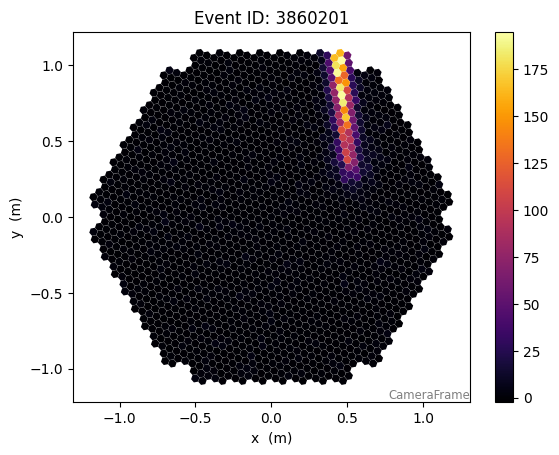

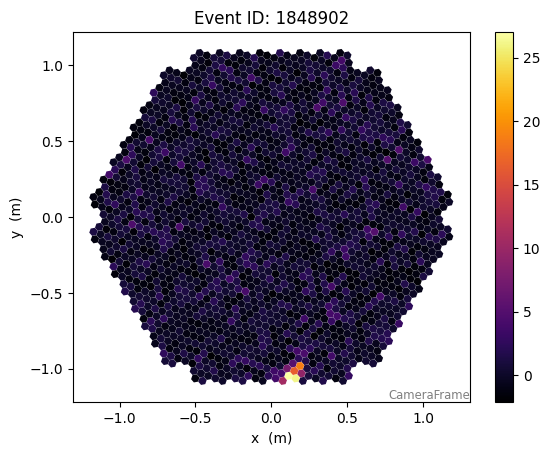

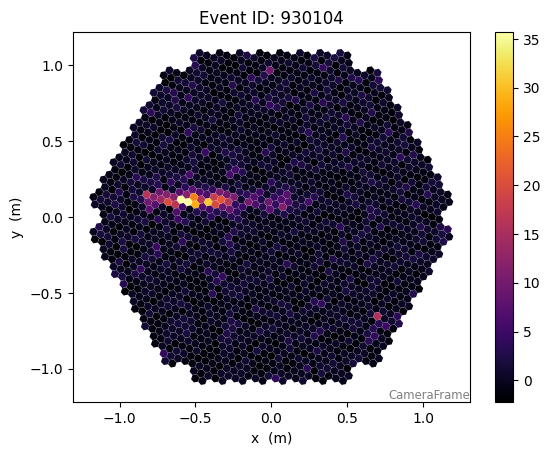

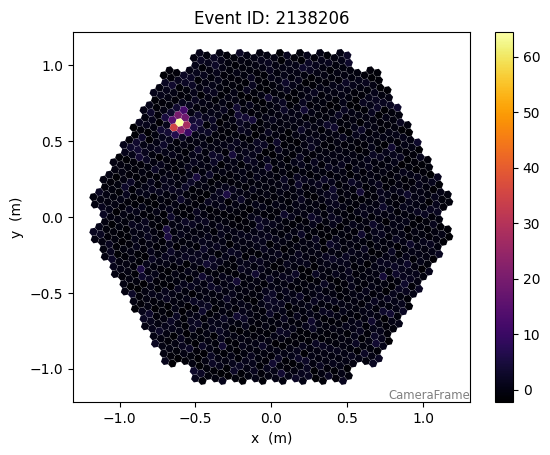

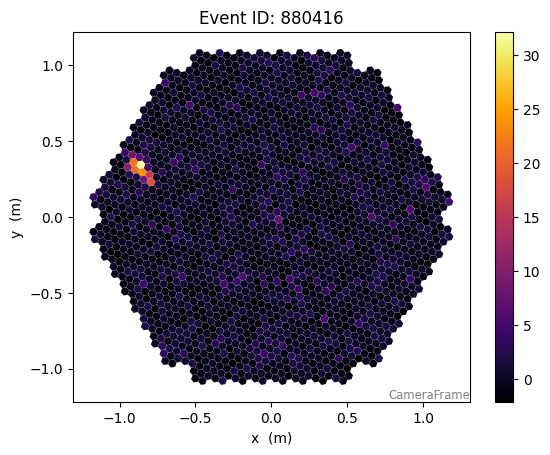

In [6]:
N=np.random.randint(0, len(mono_events), 5)
for i in N:
    event = mono_events[i]
    image = event.dl1.tel[tel_id].image #Conatins all the intesnity info
    geom = subarray.tel[tel_id].camera.geometry #Contains all x,y coordinates

    disp = CameraDisplay(geom, image=image)
    disp.add_colorbar()
    #Adding a title to the plot
    plt.title(f"Event ID: {event.index.event_id}")
    plt.show()

#### Clean the image using `tailcuts_clean` (use event id = 5) - How to decide thresholds?
#### Finding the number of island and the brightest island.
#### Finding the Hillas Parameter.

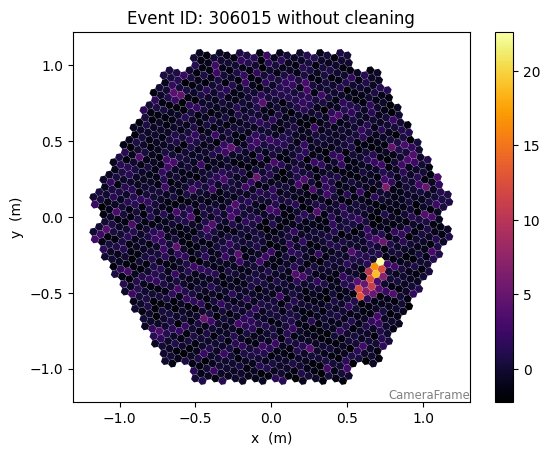

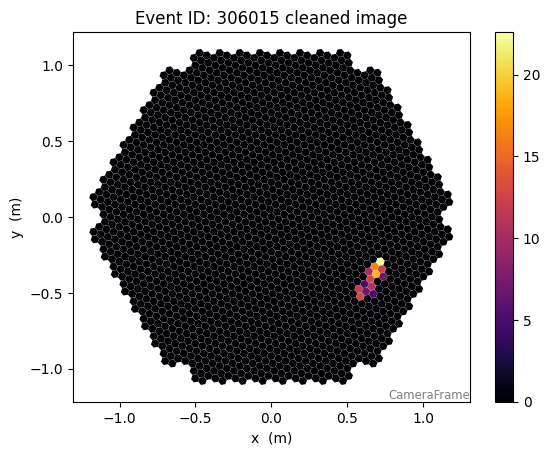

Number of islands in the image: 1
Hillas parameters of the brightest island: {'intensity': np.float64(152.89999866485596),
 'kurtosis': np.float64(1.8610171221208414),
 'length': <Quantity 0.08457558 m>,
 'length_uncertainty': <Quantity 0.00317334 m>,
 'phi': <Angle -0.5367505 rad>,
 'psi': <Angle 1.0281727 rad>,
 'psi_uncertainty': <Angle 0.05619546 rad>,
 'r': <Quantity 0.77521606 m>,
 'skewness': np.float64(-0.34086483382918864),
 'transverse_cog_uncertainty': <Quantity 0.00368772 m>,
 'width': <Quantity 0.0265511 m>,
 'width_uncertainty': <Quantity 0.0014784 m>,
 'x': <Quantity 0.66620118 m>,
 'y': <Quantity -0.39640376 m>}


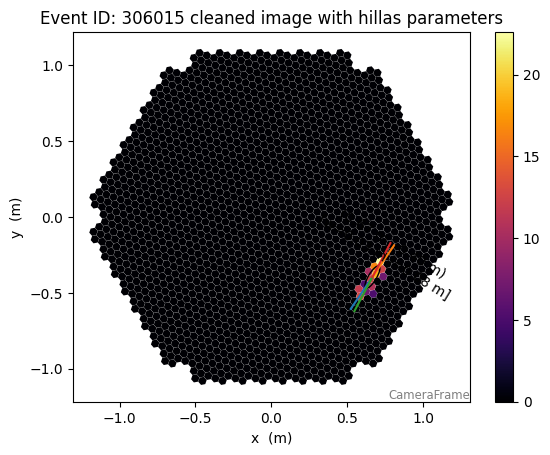

In [7]:
#Plotting the initial image without any clean up
event_5=mono_events[5]
image_5 = event_5.dl1.tel[tel_id].image #considering only the 5th event for analysis
geom = subarray.tel[tel_id].camera.geometry
disp = CameraDisplay(geom, image=image_5)
disp.add_colorbar()
plt.title(f"Event ID: {event_5.index.event_id} without cleaning")
plt.show()

#Adding the cleaned image
#This is to remove the noise pixels
clean_mask = tailcuts_clean(geom, image_5, picture_thresh=10, boundary_thresh=5)
#picture_thresh is to select the strongest pixel in the image. 
#boundary_thresh comsiders the min imtensity of the pixels surrounding the main shower.
clean_image_5 = image_5.copy()
clean_image_5[~clean_mask] = 0

disp = CameraDisplay(geom, image=clean_image_5)
disp.add_colorbar()

plt.title(f"Event ID: {event_5.index.event_id} cleaned image")
plt.show()



#Finding the number of islands in the image
n_islands_5, island_labels_5 = number_of_islands(geom, clean_mask)
print(f"Number of islands in the image: {n_islands_5}")

#Saving the brightest island in the image
#The brightest island is the one with the highest total pixel intensity
mask_5 = largest_island(island_labels_5)


#combining the mask of the brightest island with the clean mask to get the final mask
final_mask_5 = clean_mask & mask_5

#Computing the hillas parameters of the brightest island
hillas_5 = hillas_parameters(geom[final_mask_5], image_5[final_mask_5])
print(f"Hillas parameters of the brightest island: {hillas_5}")

#Plotting the cleaned image with the hillas parameters
disp = CameraDisplay(geom, image=clean_image_5)
disp.overlay_moments(hillas_5)
disp.add_colorbar()
plt.title(f"Event ID: {event_5.index.event_id} cleaned image with hillas parameters")
plt.show()


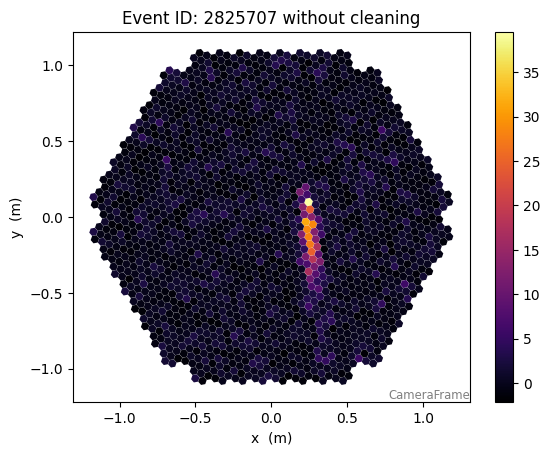

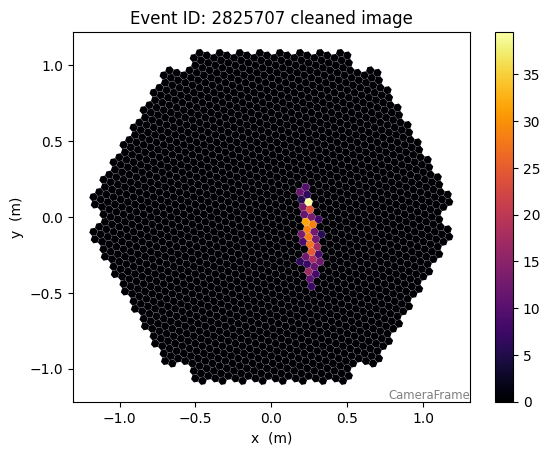

Number of islands in the image: 1
Hillas parameters of the brightest island: {'intensity': np.float64(499.7000026702881),
 'kurtosis': np.float64(2.2044209132111154),
 'length': <Quantity 0.1581769 m>,
 'length_uncertainty': <Quantity 0.00388282 m>,
 'phi': <Angle -0.42010185 rad>,
 'psi': <Angle -1.49001507 rad>,
 'psi_uncertainty': <Angle 0.01407091 rad>,
 'r': <Quantity 0.27713249 m>,
 'skewness': np.float64(0.058707088163374874),
 'transverse_cog_uncertainty': <Quantity 0.00203989 m>,
 'width': <Quantity 0.02951575 m>,
 'width_uncertainty': <Quantity 0.00092796 m>,
 'x': <Quantity 0.2530351 m>,
 'y': <Quantity -0.11302944 m>}


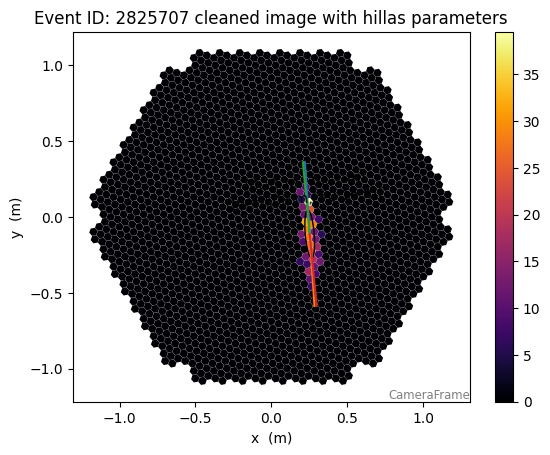

In [ ]:
#Plotting the initial image without any clean up
event=mono_events[1001]
image = event.dl1.tel[tel_id].image #considering only the 5th event for analysis
geom = subarray.tel[tel_id].camera.geometry
disp = CameraDisplay(geom, image=image)
disp.add_colorbar()
plt.title(f"Event ID: {event.index.event_id} without cleaning")
plt.show()

#Adding the cleaned image
#This is to remove the noise pixels
clean_mask = tailcuts_clean(geom, image, picture_thresh=10, boundary_thresh=5)
#picture_thresh is to select the strongest pixel in the image. 
#boundary_thresh comsiders the min imtensity of the pixels surrounding the main shower.
clean_image = image.copy()
clean_image[~clean_mask] = 0

disp = CameraDisplay(geom, image=clean_image)
disp.add_colorbar()

plt.title(f"Event ID: {event.index.event_id} cleaned image")
plt.show()



#Finding the number of islands in the image
n_islands, island_labels = number_of_islands(geom, clean_mask)
print(f"Number of islands in the image: {n_islands}")

#Saving the brightest island in the image
#The brightest island is the one with the highest total pixel intensity
mask = largest_island(island_labels)


#combining the mask of the brightest island with the clean mask to get the final mask
final_mask = clean_mask & mask

#Making the final image
final_image = clean_image * final_mask

#Computing the hillas parameters of the brightest island
hillas = hillas_parameters(geom[final_mask], image[final_mask])
print(f"Hillas parameters of the brightest island: {hillas}")

#Plotting the cleaned image with the hillas parameters
disp = CameraDisplay(geom, image=final_image)
disp.overlay_moments(hillas)
disp.add_colorbar()
plt.title(f"Event ID: {event.index.event_id} cleaned image with hillas parameters")
plt.show()


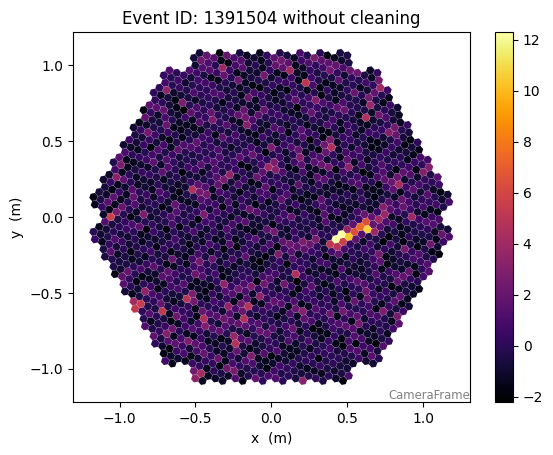

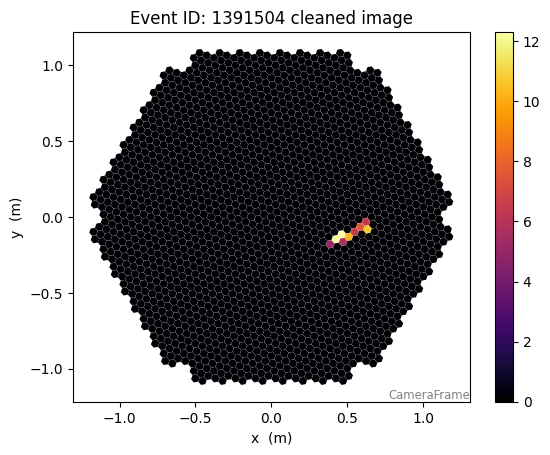

Number of islands in the image: 1
Hillas parameters of the brightest island: {'intensity': np.float64(76.59999990463257),
 'kurtosis': np.float64(1.707883164523195),
 'length': <Quantity 0.08823118 m>,
 'length_uncertainty': <Quantity 0.0042409 m>,
 'phi': <Angle -0.21477154 rad>,
 'psi': <Angle 0.43499315 rad>,
 'psi_uncertainty': <Angle 0.06517507 rad>,
 'r': <Quantity 0.5274389 m>,
 'skewness': np.float64(0.1653943632248588),
 'transverse_cog_uncertainty': <Quantity 0.00521011 m>,
 'width': <Quantity 0.01750016 m>,
 'width_uncertainty': <Quantity 0.00082748 m>,
 'x': <Quantity 0.51532105 m>,
 'y': <Quantity -0.11241001 m>}


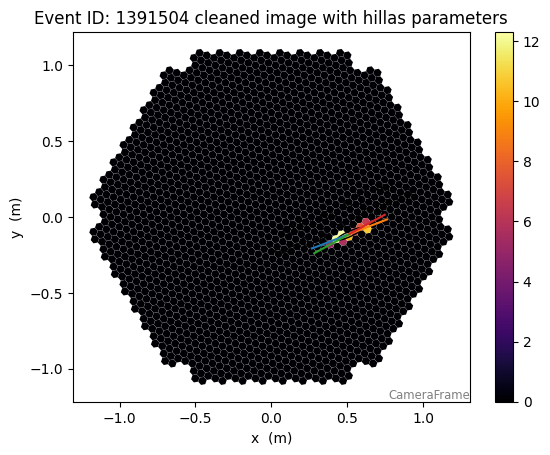

In [ ]:
#Plotting the initial image without any clean up
event=mono_events[50]
image = event.dl1.tel[tel_id].image #considering only the 5th event for analysis
geom = subarray.tel[tel_id].camera.geometry
disp = CameraDisplay(geom, image=image)
disp.add_colorbar()
plt.title(f"Event ID: {event.index.event_id} without cleaning")
plt.show()

#Adding the cleaned image
#This is to remove the noise pixels
clean_mask = tailcuts_clean(geom, image, picture_thresh=10, boundary_thresh=5)
#picture_thresh is to select the strongest pixel in the image. 
#boundary_thresh comsiders the min imtensity of the pixels surrounding the main shower.
clean_image = image.copy()
clean_image[~clean_mask] = 0

disp = CameraDisplay(geom, image=clean_image)
disp.add_colorbar()

plt.title(f"Event ID: {event.index.event_id} cleaned image")
plt.show()



#Finding the number of islands in the image
n_islands, island_labels = number_of_islands(geom, clean_mask)
print(f"Number of islands in the image: {n_islands}")

#Saving the brightest island in the image
#The brightest island is the one with the highest total pixel intensity
mask = largest_island(island_labels)


#combining the mask of the brightest island with the clean mask to get the final mask
final_mask = clean_mask & mask

#Making the final image
final_image = clean_image * final_mask

#Computing the hillas parameters of the brightest island
hillas = hillas_parameters(geom[final_mask], image[final_mask])
print(f"Hillas parameters of the brightest island: {hillas}")

#Plotting the cleaned image with the hillas parameters
disp = CameraDisplay(geom, image=final_image)
disp.overlay_moments(hillas)
disp.add_colorbar()
plt.title(f"Event ID: {event.index.event_id} cleaned image with hillas parameters")
plt.show()


#### Plotting the arrival time of each pixel and the timing profile

We will consider the mono_event[11]

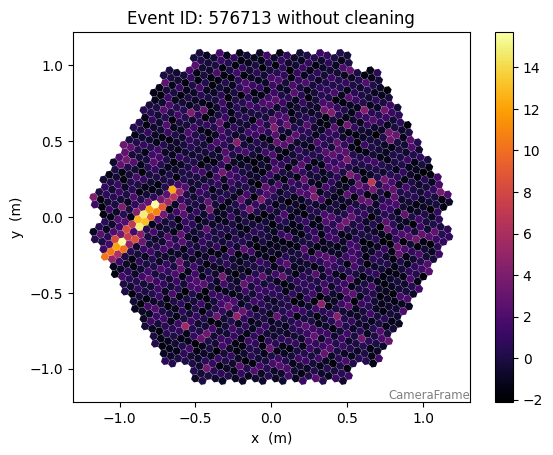

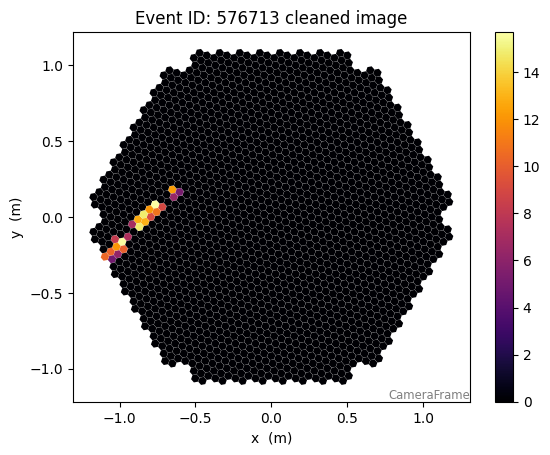

Number of islands in the image: 3
Hillas parameters of the brightest island: {'intensity': np.float64(119.20000076293945),
 'kurtosis': np.float64(1.759699569700135),
 'length': <Quantity 0.06900523 m>,
 'length_uncertainty': <Quantity 0.00275445 m>,
 'phi': <Angle 3.13009824 rad>,
 'psi': <Angle 0.71481332 rad>,
 'psi_uncertainty': <Angle 0.07793685 rad>,
 'r': <Quantity 0.81756007 m>,
 'skewness': np.float64(0.04544883864928285),
 'transverse_cog_uncertainty': <Quantity 0.0041766 m>,
 'width': <Quantity 0.0216266 m>,
 'width_uncertainty': <Quantity 9.34271387e-05 m>,
 'x': <Quantity -0.81750606 m>,
 'y': <Quantity 0.00939717 m>}


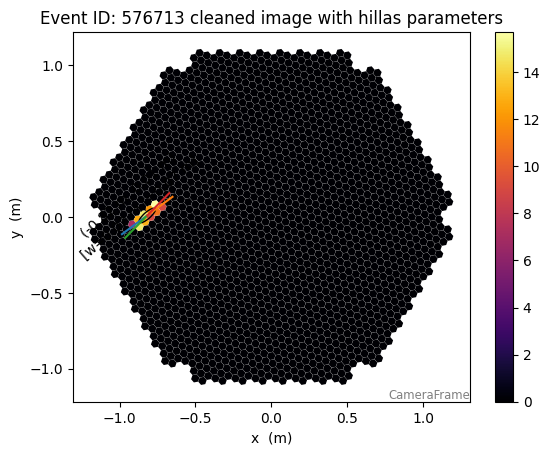

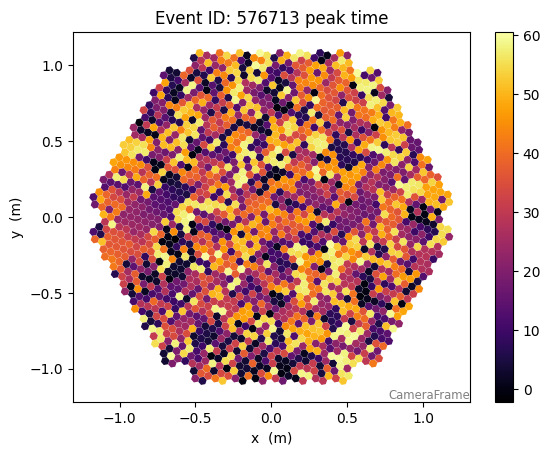

In [13]:
#Plotting the initial image without any clean up
event=mono_events[11]
image = event.dl1.tel[tel_id].image #considering only the 5th event for analysis
geom = subarray.tel[tel_id].camera.geometry
disp = CameraDisplay(geom, image=image)
disp.add_colorbar()
plt.title(f"Event ID: {event.index.event_id} without cleaning")
plt.show()

#Adding the cleaned image
#This is to remove the noise pixels
clean_mask = tailcuts_clean(geom, image, picture_thresh=10, boundary_thresh=5)
#picture_thresh is to select the strongest pixel in the image. 
#boundary_thresh comsiders the min imtensity of the pixels surrounding the main shower.
clean_image = image.copy()
clean_image[~clean_mask] = 0

disp = CameraDisplay(geom, image=clean_image)
disp.add_colorbar()

plt.title(f"Event ID: {event.index.event_id} cleaned image")
plt.show()



#Finding the number of islands in the image
n_islands, island_labels = number_of_islands(geom, clean_mask)
print(f"Number of islands in the image: {n_islands}")

#Saving the brightest island in the image
#The brightest island is the one with the highest total pixel intensity
mask = largest_island(island_labels)


#combining the mask of the brightest island with the clean mask to get the final mask
final_mask = clean_mask & mask

#Making the final image
final_image = clean_image * final_mask

#Computing the hillas parameters of the brightest island
hillas = hillas_parameters(geom[final_mask], image[final_mask])
print(f"Hillas parameters of the brightest island: {hillas}")

#Plotting the cleaned image with the hillas parameters
disp = CameraDisplay(geom, image=final_image)
disp.overlay_moments(hillas)
disp.add_colorbar()
plt.title(f"Event ID: {event.index.event_id} cleaned image with hillas parameters")
plt.show()


peak_time=event.dl1.tel[tel_id].peak_time

disp = CameraDisplay(geom, image=peak_time)
disp.add_colorbar()
plt.title(f"Event ID: {event.index.event_id} peak time")
plt.show()


#### Timing Parameters -

In [14]:
#Now for the timing profile we basically compute the time gradient along the Hillas axis.

timing = timing_parameters(geom,image=final_image,peak_time=peak_time,hillas_parameters=hillas)
print(f"Timing parameters: {timing}")

Timing parameters: {'deviation': 18.140130616483233,
 'intercept': np.float64(23.29084651313699),
 'slope': <Quantity 10.84591877 1 / m>}


In [15]:
# Loop through all mono events and find number of islands for all the events in Telescope with tel_id = 10

for i, event in enumerate(mono_events):

    image = event.dl1.tel[tel_id].image
    geom = subarray.tel[tel_id].camera.geometry

    # Tailcuts cleaning
    clean_mask = tailcuts_clean(geom, image, picture_thresh=10, boundary_thresh=5)

    # Find islands
    n_islands, island_labels = number_of_islands(geom, clean_mask)

    print(f"Event {i+1} (Event ID: {event.index.event_id}) -> Number of islands: {n_islands}")

Event 1 (Event ID: 74804) -> Number of islands: 1
Event 2 (Event ID: 165408) -> Number of islands: 3
Event 3 (Event ID: 165410) -> Number of islands: 0
Event 4 (Event ID: 178009) -> Number of islands: 1
Event 5 (Event ID: 178016) -> Number of islands: 1
Event 6 (Event ID: 306015) -> Number of islands: 1
Event 7 (Event ID: 330713) -> Number of islands: 1
Event 8 (Event ID: 397919) -> Number of islands: 1
Event 9 (Event ID: 559900) -> Number of islands: 1
Event 10 (Event ID: 576707) -> Number of islands: 1
Event 11 (Event ID: 576709) -> Number of islands: 2
Event 12 (Event ID: 576713) -> Number of islands: 3
Event 13 (Event ID: 616707) -> Number of islands: 1
Event 14 (Event ID: 675901) -> Number of islands: 1
Event 15 (Event ID: 676111) -> Number of islands: 1
Event 16 (Event ID: 679013) -> Number of islands: 1
Event 17 (Event ID: 691504) -> Number of islands: 1
Event 18 (Event ID: 702400) -> Number of islands: 1
Event 19 (Event ID: 706418) -> Number of islands: 1
Event 20 (Event ID: 70

#### Doing all these for 1000events and then plot the hillas parameter wrt energy

In [21]:
#The important arrays
energy=[]
width=[]
length=[]
timing_P=[]
geom = subarray.tel[tel_id].camera.geometry

for n in range(1500):

    event = mono_events[n]

    image = event.dl1.tel[tel_id].image
    peak_time = event.dl1.tel[tel_id].peak_time

    # Tailcuts cleaning
    clean_mask = tailcuts_clean(
        geom, image,
        picture_thresh=10,
        boundary_thresh=5
    )

    # Find islands
    n_islands, island_labels = number_of_islands(geom, clean_mask)

    if n_islands == 0:
        continue

    # Brightest island
    mask = largest_island(island_labels)
    final_mask = clean_mask & mask

    clean_image = image * final_mask

    # Hillas parameters
    hillas = hillas_parameters(geom, clean_image)

    # Timing parameters
    timing = timing_parameters(
        geom=geom,
        image=clean_image,
        peak_time=peak_time,
        hillas_parameters=hillas,
        cleaning_mask=final_mask
    )

    # Store values
    energy.append(event.simulation.shower.energy.to_value()) 
    width.append(hillas.width.to_value())
    length.append(hillas.length.to_value())
    timing_P.append(timing.slope.to_value())

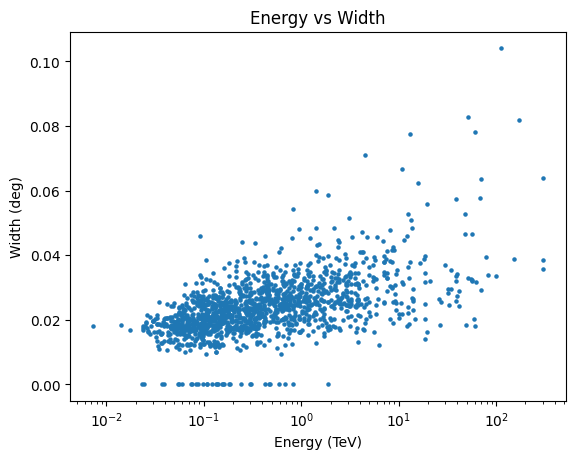

In [22]:
#Plotting the energy vs width
plt.scatter(energy, width, s=5)

plt.xscale("log")
plt.xlabel("Energy (TeV)")
plt.ylabel("Width (deg)")
plt.title("Energy vs Width")

plt.show()

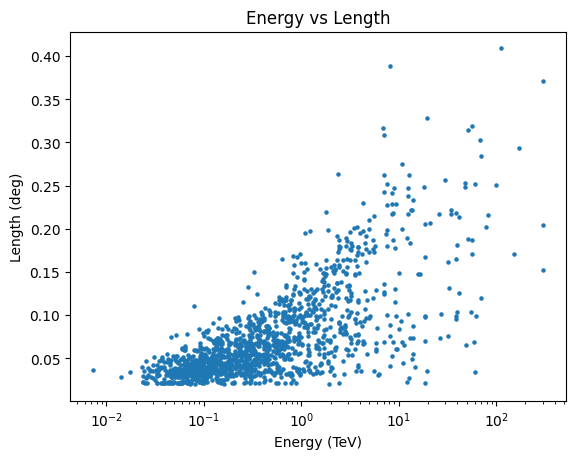

In [23]:
#Plotting energy with length
plt.scatter(energy, length, s=5)
plt.xscale("log")
plt.xlabel("Energy (TeV)")
plt.ylabel("Length (deg)")
plt.title("Energy vs Length")
plt.show()

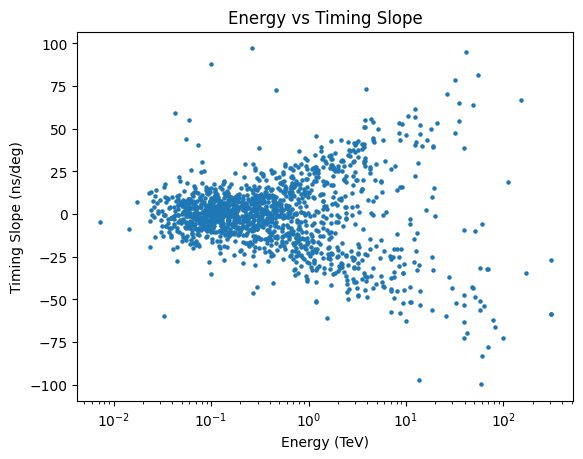

In [24]:
#Plotting the energy vs slope of the timing profile
plt.scatter(energy, timing_P, s=5)
plt.xscale("log")
plt.xlabel("Energy (TeV)")
plt.ylabel("Timing Slope (ns/deg)")
plt.title("Energy vs Timing Slope")
plt.show()